In [1]:
"""
Dog vs Cat Image Classifier
Author: [Your Name]
Description: Build a simple neural network to classify dog and cat images
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
Keras version: 3.13.2
GPU available: []


Loading CIFAR-10 dataset...
Full dataset shape - Training: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)
Full dataset labels - Training: (50000, 1), Test: (10000, 1)

CIFAR-10 classes:
  0: airplane
  1: automobile
  2: bird
  3: cat
  4: deer
  5: dog
  6: frog
  7: horse
  8: ship
  9: truck

Filtered dataset:
  Training: 10000 images
  Test: 2000 images
  Image shape: (32, 32, 3)

Training set - Cats: 5000, Dogs: 5000
Test set - Cats: 1000, Dogs: 1000

Flattened shape: (10000, 3072)

Saved sample images to 'sample_images.png'


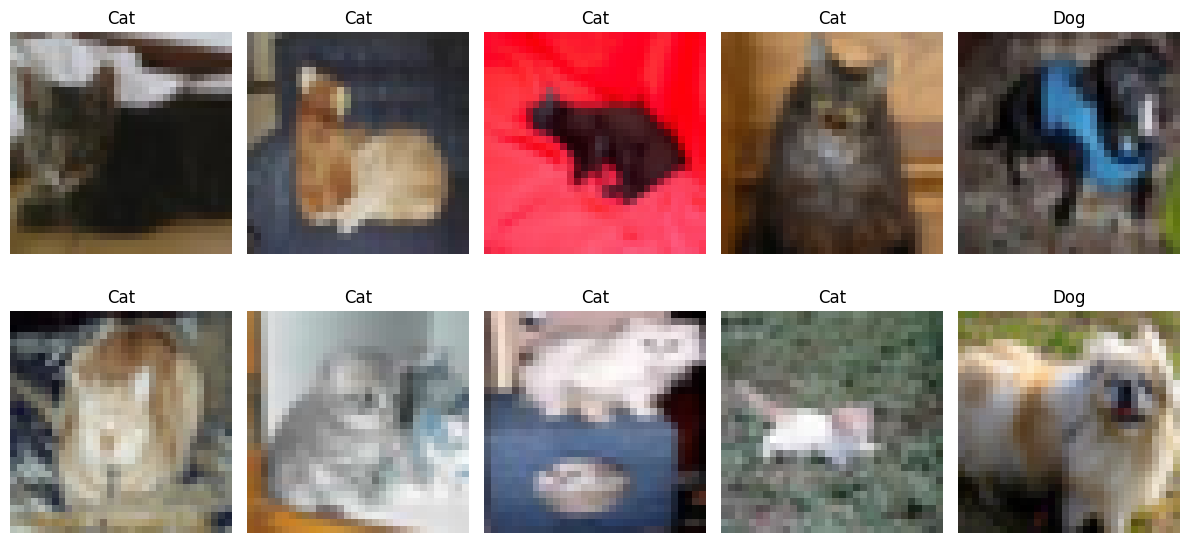

In [5]:
# Load CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

print(f"Full dataset shape - Training: {x_train_full.shape}, Test: {x_test_full.shape}")
print(f"Full dataset labels - Training: {y_train_full.shape}, Test: {y_test_full.shape}")

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

print("\nCIFAR-10 classes:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

# Filter to cats (3) and dogs (5)
cat_class = 3
dog_class = 5

# Training set
train_cat_mask = (y_train_full.flatten() == cat_class)
train_dog_mask = (y_train_full.flatten() == dog_class)
train_mask = train_cat_mask | train_dog_mask

x_train = x_train_full[train_mask]
y_train = y_train_full[train_mask]

# Convert labels: cat=0, dog=1
y_train = np.where(y_train == cat_class, 0, 1)

# Test set
test_cat_mask = (y_test_full.flatten() == cat_class)
test_dog_mask = (y_test_full.flatten() == dog_class)
test_mask = test_cat_mask | test_dog_mask

x_test = x_test_full[test_mask]
y_test = y_test_full[test_mask]

# Convert labels: cat=0, dog=1
y_test = np.where(y_test == dog_class, 1, 0)

print(f"\nFiltered dataset:")
print(f"  Training: {x_train.shape[0]} images")
print(f"  Test: {x_test.shape[0]} images")
print(f"  Image shape: {x_train.shape[1:]}")

# Check class distribution
print(f"\nTraining set - Cats: {(y_train == 0).sum()}, Dogs: {(y_train == 1).sum()}")
print(f"Test set - Cats: {(y_test == 0).sum()}, Dogs: {(y_test == 1).sum()}")

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten images for simple neural network (32x32x3 = 3072)
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

print(f"\nFlattened shape: {x_train_flat.shape}")

# Visualize some sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    row = i // 5
    col = i % 5
    axes[row, col].imshow(x_train[i])
    label = 'Cat' if y_train[i] == 0 else 'Dog'
    axes[row, col].set_title(f'{label}')
    axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
print("\nSaved sample images to 'sample_images.png'")
plt.show()


In [3]:
# Build the neural network
print("\n" + "="*50)
print("BUILDING NEURAL NETWORK")
print("="*50)

# Simple feedforward neural network
model = keras.Sequential([
    # Input layer: 3072 features (32*32*3)
    layers.Dense(128, activation='relu', input_shape=(3072,), name='hidden_layer_1'),
    layers.Dense(64, activation='relu', name='hidden_layer_2'),
    # Output layer: 1 neuron for binary classification (dog or cat)
    layers.Dense(1, activation='sigmoid', name='output_layer')
])

# Compile the model
model.compile(
    optimizer='adam',           # Optimization algorithm
    loss='binary_crossentropy', # Loss function for binary classification
    metrics=['accuracy']        # Metric to track during training
)

# Display model architecture
print("\nModel Architecture:")
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")



BUILDING NEURAL NETWORK


c:\Users\pbiai\miniconda3\envs\ironhack_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401,665 (1.53 MB)

 Trainable params: 401,665 (1.53 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 401,665


In [6]:
# Train the model
print("\n" + "="*50)
print("TRAINING THE MODEL")
print("="*50)

# Training parameters
EPOCHS = 20
BATCH_SIZE = 32

print(f"Training for {EPOCHS} epochs with batch size {BATCH_SIZE}...")

# Train the model
history = model.fit(
    x_train_flat, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_test_flat, y_test),
    verbose=1  # Show progress bar
)

print("\n✓ Training complete!")



TRAINING THE MODEL
Training for 20 epochs with batch size 32...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5548 - loss: 0.6952 - val_accuracy: 0.5970 - val_loss: 0.6684
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5761 - loss: 0.6728 - val_accuracy: 0.6025 - val_loss: 0.6630
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5823 - loss: 0.6701 - val_accuracy: 0.5975 - val_loss: 0.6752
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5907 - loss: 0.6669 - val_accuracy: 0.5890 - val_loss: 0.6706
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6017 - loss: 0.6612 - val_accuracy: 0.5910 - val_loss: 0.6692
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6035 - loss: 0.6584 - val_accuracy: 0.5940 - val_loss: 0.6664
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6041 - loss: 0.6571 - val_accuracy: 0.5910 - val_loss: 0.6677
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━


EVALUATING THE MODEL
Test Loss: 0.6627
Test Accuracy: 0.6000 (60.00%)
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Manual accuracy check: 1200/2000 (60.00%)

Saved training history to 'training_history.png'


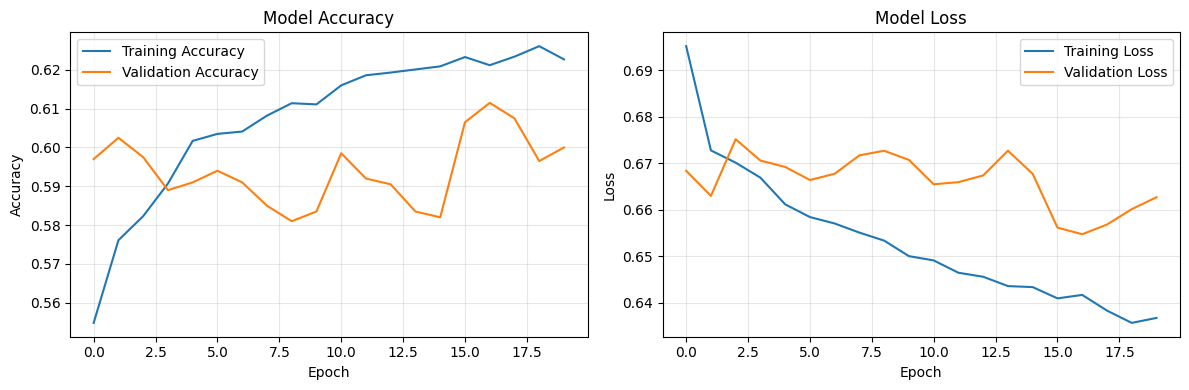


SAMPLE PREDICTIONS
Saved sample predictions to 'sample_predictions.png'


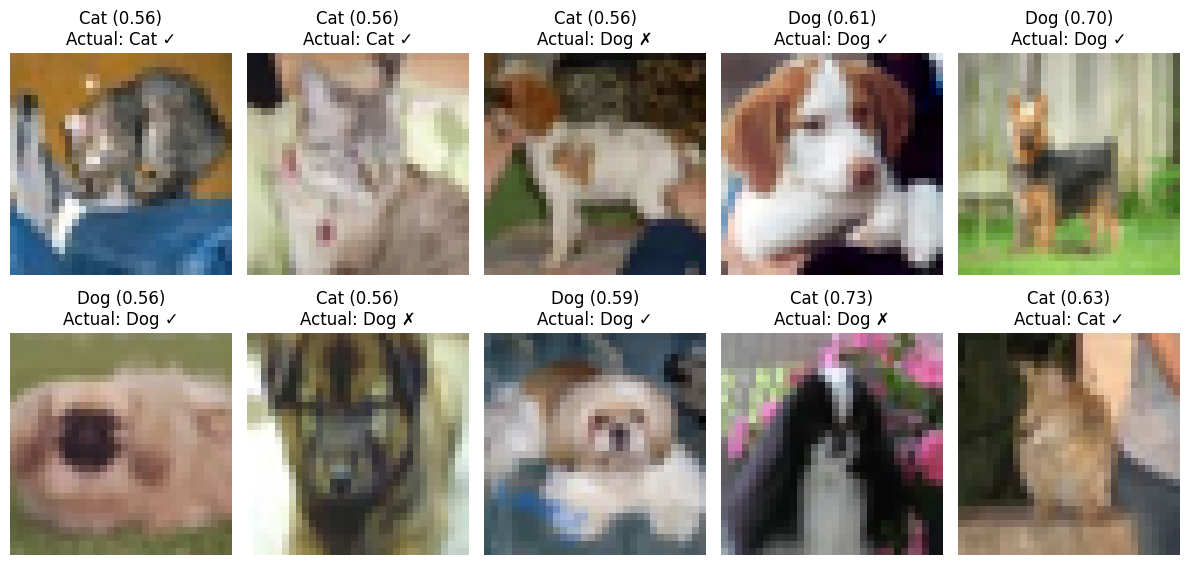

In [7]:
# Evaluate the model
print("\n" + "="*50)
print("EVALUATING THE MODEL")
print("="*50)

test_loss, test_accuracy = model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Make predictions on test set
predictions = model.predict(x_test_flat)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# Calculate accuracy manually
correct = (predicted_classes == y_test.flatten()).sum()
total = len(y_test)
print(f"\nManual accuracy check: {correct}/{total} ({correct/total*100:.2f}%)")

# Visualize training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
print("\nSaved training history to 'training_history.png'")
plt.show()

# Test on some sample images
print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    row = i // 5
    col = i % 5
    
    # Get prediction
    img = x_test[i].reshape(1, -1)
    pred = model.predict(img, verbose=0)[0][0]
    pred_class = 'Dog' if pred > 0.5 else 'Cat'
    confidence = pred if pred > 0.5 else 1 - pred
    
    # Actual label
    actual = 'Dog' if y_test[i] == 1 else 'Cat'
    correct = '✓' if (pred > 0.5) == (y_test[i] == 1) else '✗'
    
    axes[row, col].imshow(x_test[i])
    axes[row, col].set_title(f'{pred_class} ({confidence:.2f})\nActual: {actual} {correct}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
print("Saved sample predictions to 'sample_predictions.png'")
plt.show()


In [10]:
# Export model weights
print("\n" + "="*50)
print("EXPORTING MODEL WEIGHTS")
print("="*50)

# Create directory for saved models
import os
os.makedirs('saved_models', exist_ok=True)

# Method 1: Save entire model (architecture + weights + optimizer state)
model_path = 'saved_models/dog_cat_classifier_full.h5'
model.save(model_path)
print(f"✓ Saved full model to: {model_path}")
print(f"  File size: {os.path.getsize(model_path) / 1024 / 1024:.2f} MB")

# Method 2: Save only weights
weights_path = 'saved_models/dog_cat_classifier.weights.h5'
model.save_weights(weights_path)
print(f"✓ Saved weights only to: {weights_path}")
print(f"  File size: {os.path.getsize(weights_path) / 1024 / 1024:.2f} MB")

# Method 3: Save in native Keras format (recommended in Keras 3)
savedmodel_path = 'saved_models/dog_cat_classifier.keras'
model.save(savedmodel_path)
print(f"✓ Saved in Keras format to: {savedmodel_path}")
print(f"  File size: {os.path.getsize(savedmodel_path) / 1024 / 1024:.2f} MB")

# Verify we can load the model
print("\nVerifying saved model...")
loaded_model = keras.models.load_model(savedmodel_path)  # load the .keras file instead
test_loss_loaded, test_acc_loaded = loaded_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Loaded model test accuracy: {test_acc_loaded:.4f}")
print(f"Original model test accuracy: {test_accuracy:.4f}")
print(f"Match: {'✓' if abs(test_acc_loaded - test_accuracy) < 0.001 else '✗'}")

print("\n✓ Model weights exported successfully!")



EXPORTING MODEL WEIGHTS
✓ Saved full model to: saved_models/dog_cat_classifier_full.h5
  File size: 4.63 MB
✓ Saved weights only to: saved_models/dog_cat_classifier.weights.h5
  File size: 4.62 MB
✓ Saved in Keras format to: saved_models/dog_cat_classifier.keras
  File size: 4.62 MB

Verifying saved model...


c:\Users\pbiai\miniconda3\envs\ironhack_env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loaded model test accuracy: 0.6000
Original model test accuracy: 0.6000
Match: ✓

✓ Model weights exported successfully!


In [11]:
import time

# ── Define experiments ──────────────────────────────────────────────────────
layer_configs = {
    "1 layer  (128)":           [128],
    "2 layers (128→64)":        [128, 64],
    "3 layers (128→64→32)":     [128, 64, 32],
    "4 layers (128→64→32→16)":  [128, 64, 32, 16],
}

histories   = {}
accuracies  = {}
train_times = {}

# ── Train each config ────────────────────────────────────────────────────────
for name, layer_sizes in layer_configs.items():
    print(f"\nTraining: {name}")

    # Build model dynamically
    m = keras.Sequential()
    for i, units in enumerate(layer_sizes):
        if i == 0:
            m.add(layers.Dense(units, activation='relu', input_shape=(3072,)))
        else:
            m.add(layers.Dense(units, activation='relu'))
    m.add(layers.Dense(1, activation='sigmoid'))

    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train and time it
    start = time.time()
    h = m.fit(x_train_flat, y_train,
              batch_size=32, epochs=20,
              validation_data=(x_test_flat, y_test),
              verbose=0)  # silent — results shown in charts
    elapsed = time.time() - start

    histories[name]   = h
    accuracies[name]  = h.history['val_accuracy'][-1]
    train_times[name] = elapsed
    print(f"  → val accuracy: {accuracies[name]*100:.2f}%  |  time: {elapsed:.1f}s")


Training: 1 layer  (128)
  → val accuracy: 50.00%  |  time: 40.2s

Training: 2 layers (128→64)
  → val accuracy: 57.45%  |  time: 40.1s

Training: 3 layers (128→64→32)
  → val accuracy: 58.05%  |  time: 38.5s

Training: 4 layers (128→64→32→16)
  → val accuracy: 59.65%  |  time: 37.2s


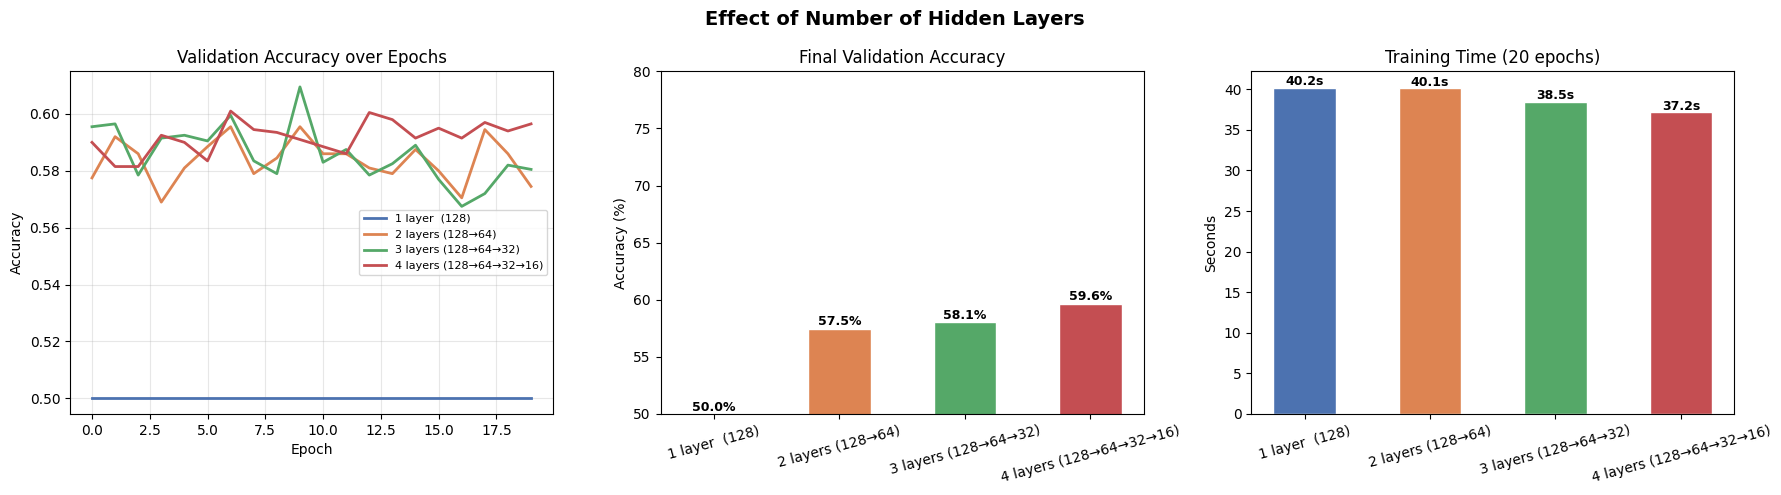

Saved → experiment_layers.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Effect of Number of Hidden Layers", fontsize=14, fontweight='bold')

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# ── Chart 1: Validation accuracy curves ─────────────────────────────────────
for (name, h), color in zip(histories.items(), colors):
    axes[0].plot(h.history['val_accuracy'], label=name, color=color, linewidth=2)
axes[0].set_title('Validation Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── Chart 2: Final accuracy bar chart ───────────────────────────────────────
names = list(accuracies.keys())
vals  = [v * 100 for v in accuracies.values()]
bars  = axes[1].bar(names, vals, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Final Validation Accuracy')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(50, 80)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# ── Chart 3: Training time bar chart ────────────────────────────────────────
times = list(train_times.values())
bars2 = axes[2].bar(names, times, color=colors, edgecolor='white', width=0.5)
axes[2].set_title('Training Time (20 epochs)')
axes[2].set_ylabel('Seconds')
axes[2].tick_params(axis='x', rotation=15)
for bar, t in zip(bars2, times):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{t:.1f}s', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('experiment_layers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → experiment_layers.png")

In [13]:
# Compare TRAINING accuracy vs VALIDATION accuracy
for name, h in histories.items():
    train_acc = h.history['accuracy'][-1]
    val_acc   = h.history['val_accuracy'][-1]
    gap       = train_acc - val_acc
    print(f"{name}: train={train_acc:.3f}  val={val_acc:.3f}  gap={gap:.3f}")

1 layer  (128): train=0.493  val=0.500  gap=-0.007
2 layers (128→64): train=0.641  val=0.575  gap=0.067
3 layers (128→64→32): train=0.634  val=0.581  gap=0.053
4 layers (128→64→32→16): train=0.637  val=0.596  gap=0.041


In [15]:
import time

# ── Define neuron experiments ────────────────────────────────────────────────
neuron_configs = {
    "32 neurons":  [32],
    "64 neurons":  [64],
    "128 neurons": [128],
    "256 neurons": [256],
    "512 neurons": [512],
}

histories_n   = {}
accuracies_n  = {}
train_times_n = {}

# ── Train each config ─────────────────────────────────────────────────────────
for name, units_list in neuron_configs.items():
    print(f"\nTraining: {name}")

    m = keras.Sequential([
        layers.Dense(units_list[0], activation='relu', input_shape=(3072,)),
        layers.Dense(1, activation='sigmoid')  # single hidden layer, width varies
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    start = time.time()
    h = m.fit(x_train_flat, y_train,
              batch_size=32, epochs=20,
              validation_data=(x_test_flat, y_test),
              verbose=0)
    elapsed = time.time() - start

    # Check overfitting gap
    train_acc = h.history['accuracy'][-1]
    val_acc   = h.history['val_accuracy'][-1]
    gap       = train_acc - val_acc

    histories_n[name]   = h
    accuracies_n[name]  = val_acc
    train_times_n[name] = elapsed
    print(f"  → train: {train_acc:.3f}  val: {val_acc:.3f}  gap: {gap:.3f}  time: {elapsed:.1f}s")


Training: 32 neurons
  → train: 0.620  val: 0.607  gap: 0.014  time: 31.4s

Training: 64 neurons
  → train: 0.629  val: 0.594  gap: 0.035  time: 27.3s

Training: 128 neurons
  → train: 0.493  val: 0.500  gap: -0.007  time: 38.6s

Training: 256 neurons
  → train: 0.649  val: 0.603  gap: 0.046  time: 58.1s

Training: 512 neurons
  → train: 0.638  val: 0.602  gap: 0.036  time: 90.6s


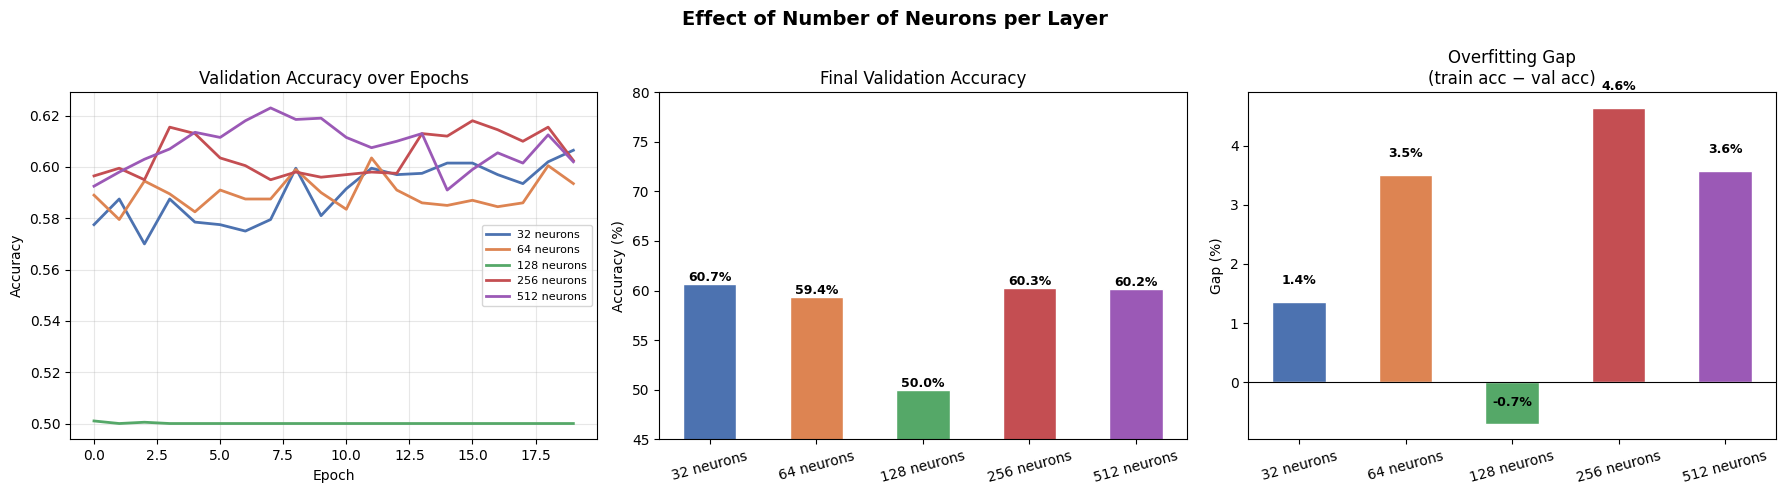

Saved → experiment_neurons.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Effect of Number of Neurons per Layer", fontsize=14, fontweight='bold')

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#9B59B6']

# ── Chart 1: Validation accuracy curves ──────────────────────────────────────
for (name, h), color in zip(histories_n.items(), colors):
    axes[0].plot(h.history['val_accuracy'], label=name, color=color, linewidth=2)
axes[0].set_title('Validation Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── Chart 2: Final accuracy bar chart ────────────────────────────────────────
names = list(accuracies_n.keys())
vals  = [v * 100 for v in accuracies_n.values()]
bars  = axes[1].bar(names, vals, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Final Validation Accuracy')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(45, 80)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# ── Chart 3: Overfitting gap ──────────────────────────────────────────────────
gaps = [h.history['accuracy'][-1] - h.history['val_accuracy'][-1] 
        for h in histories_n.values()]
bars2 = axes[2].bar(names, [g * 100 for g in gaps], color=colors, edgecolor='white', width=0.5)
axes[2].set_title('Overfitting Gap\n(train acc − val acc)')
axes[2].set_ylabel('Gap (%)')
axes[2].tick_params(axis='x', rotation=15)
axes[2].axhline(0, color='black', linewidth=0.8)
for bar, g in zip(bars2, gaps):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{g*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('experiment_neurons.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → experiment_neurons.png")

In [17]:
import time

# ── Define learning rate experiments ─────────────────────────────────────────
lr_configs = {
    "LR = 0.0001 (very slow)": 0.0001,
    "LR = 0.001  (default)":   0.001,
    "LR = 0.01   (fast)":      0.01,
    "LR = 0.1    (very fast)": 0.1,
}

histories_lr   = {}
accuracies_lr  = {}
train_times_lr = {}

# ── Train each config ─────────────────────────────────────────────────────────
for name, lr in lr_configs.items():
    print(f"\nTraining: {name}")

    m = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(3072,)),
        layers.Dense(64,  activation='relu'),
        layers.Dense(1,   activation='sigmoid')
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()
    h = m.fit(x_train_flat, y_train,
              batch_size=32, epochs=20,
              validation_data=(x_test_flat, y_test),
              verbose=0)
    elapsed = time.time() - start

    train_acc = h.history['accuracy'][-1]
    val_acc   = h.history['val_accuracy'][-1]
    gap       = train_acc - val_acc

    histories_lr[name]   = h
    accuracies_lr[name]  = val_acc
    train_times_lr[name] = elapsed
    print(f"  → train: {train_acc:.3f}  val: {val_acc:.3f}  gap: {gap:.3f}  time: {elapsed:.1f}s")


Training: LR = 0.0001 (very slow)
  → train: 0.687  val: 0.627  gap: 0.060  time: 50.4s

Training: LR = 0.001  (default)
  → train: 0.631  val: 0.580  gap: 0.051  time: 41.0s

Training: LR = 0.01   (fast)
  → train: 0.616  val: 0.604  gap: 0.012  time: 37.2s

Training: LR = 0.1    (very fast)
  → train: 0.494  val: 0.500  gap: -0.006  time: 36.9s


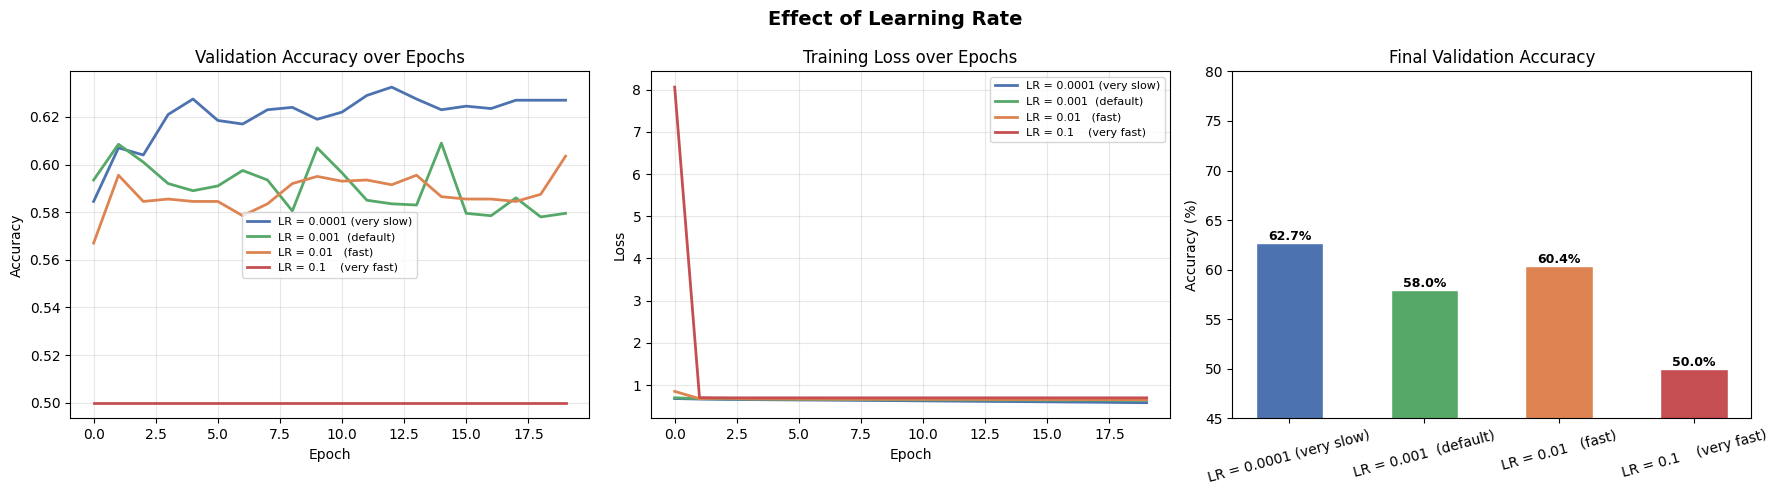

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Effect of Learning Rate", fontsize=14, fontweight='bold')

colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

for (name, h), color in zip(histories_lr.items(), colors):
    axes[0].plot(h.history['val_accuracy'], label=name, color=color, linewidth=2)
axes[0].set_title('Validation Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for (name, h), color in zip(histories_lr.items(), colors):
    axes[1].plot(h.history['loss'], label=name, color=color, linewidth=2)
axes[1].set_title('Training Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

names = list(accuracies_lr.keys())
vals  = [v * 100 for v in accuracies_lr.values()]
bars  = axes[2].bar(names, vals, color=colors, edgecolor='white', width=0.5)
axes[2].set_title('Final Validation Accuracy')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_ylim(45, 80)
axes[2].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('experiment_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
import time

batch_configs = {
    "Batch 16  (very small)": 16,
    "Batch 32  (default)":    32,
    "Batch 64  (medium)":     64,
    "Batch 128 (large)":      128,
}

histories_b   = {}
accuracies_b  = {}
train_times_b = {}

for name, batch_size in batch_configs.items():
    print(f"\nTraining: {name}")

    m = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(3072,)),
        layers.Dense(64,  activation='relu'),
        layers.Dense(1,   activation='sigmoid')
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()
    h = m.fit(x_train_flat, y_train,
              batch_size=batch_size, epochs=20,
              validation_data=(x_test_flat, y_test),
              verbose=0)
    elapsed = time.time() - start

    train_acc = h.history['accuracy'][-1]
    val_acc   = h.history['val_accuracy'][-1]
    gap       = train_acc - val_acc

    histories_b[name]   = h
    accuracies_b[name]  = val_acc
    train_times_b[name] = elapsed
    print(f"  train: {train_acc:.3f}  val: {val_acc:.3f}  gap: {gap:.3f}  time: {elapsed:.1f}s")


Training: Batch 16  (very small)
  train: 0.625  val: 0.607  gap: 0.018  time: 74.7s

Training: Batch 32  (default)
  train: 0.630  val: 0.606  gap: 0.024  time: 49.0s

Training: Batch 64  (medium)
  train: 0.647  val: 0.567  gap: 0.081  time: 24.7s

Training: Batch 128 (large)
  train: 0.620  val: 0.551  gap: 0.069  time: 16.9s


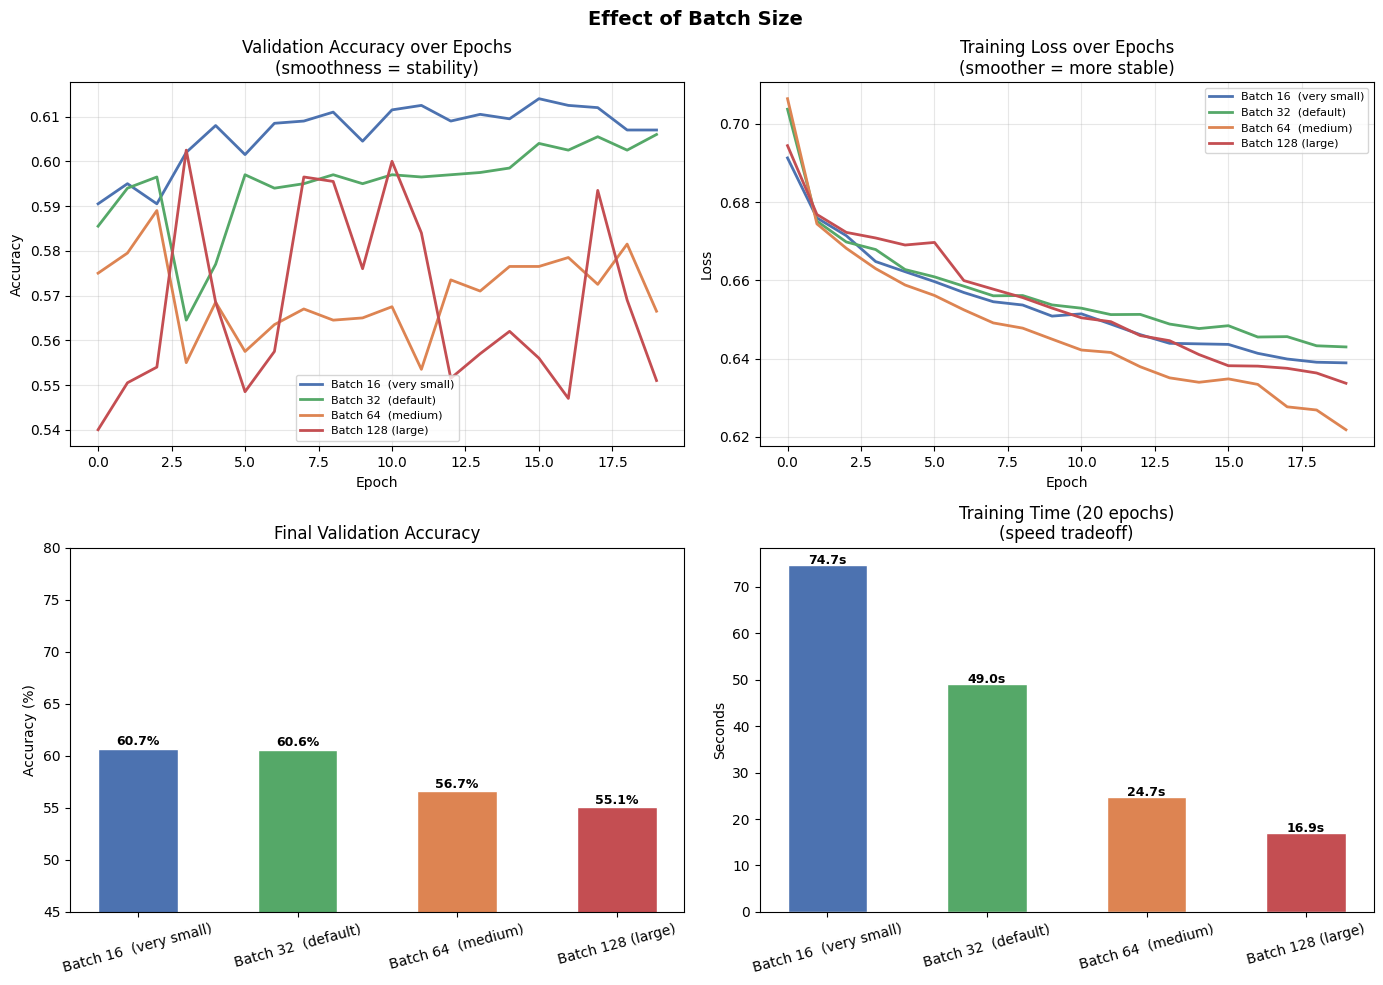

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Effect of Batch Size", fontsize=14, fontweight='bold')

colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

# Chart 1: Validation accuracy curves
for (name, h), color in zip(histories_b.items(), colors):
    axes[0,0].plot(h.history['val_accuracy'], label=name, color=color, linewidth=2)
axes[0,0].set_title('Validation Accuracy over Epochs\n(smoothness = stability)')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(alpha=0.3)

# Chart 2: Training loss curves
for (name, h), color in zip(histories_b.items(), colors):
    axes[0,1].plot(h.history['loss'], label=name, color=color, linewidth=2)
axes[0,1].set_title('Training Loss over Epochs\n(smoother = more stable)')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(alpha=0.3)

# Chart 3: Final accuracy bar chart
names = list(accuracies_b.keys())
vals  = [v * 100 for v in accuracies_b.values()]
bars  = axes[1,0].bar(names, vals, color=colors, edgecolor='white', width=0.5)
axes[1,0].set_title('Final Validation Accuracy')
axes[1,0].set_ylabel('Accuracy (%)')
axes[1,0].set_ylim(45, 80)
axes[1,0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, vals):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Chart 4: Training time bar chart
times = list(train_times_b.values())
bars2 = axes[1,1].bar(names, times, color=colors, edgecolor='white', width=0.5)
axes[1,1].set_title('Training Time (20 epochs)\n(speed tradeoff)')
axes[1,1].set_ylabel('Seconds')
axes[1,1].tick_params(axis='x', rotation=15)
for bar, t in zip(bars2, times):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{t:.1f}s', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('experiment_batch.png', dpi=150, bbox_inches='tight')
plt.show()


In [23]:
import time

epoch_configs = {
    "5 epochs":  5,
    "10 epochs": 10,
    "20 epochs": 20,
    "50 epochs": 50,
}

histories_e   = {}
accuracies_e  = {}
train_times_e = {}

for name, epochs in epoch_configs.items():
    print(f"\nTraining: {name}")

    m = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(3072,)),
        layers.Dense(64,  activation='relu'),
        layers.Dense(1,   activation='sigmoid')
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()
    h = m.fit(x_train_flat, y_train,
              batch_size=32, epochs=epochs,
              validation_data=(x_test_flat, y_test),
              verbose=0)
    elapsed = time.time() - start

    train_acc = h.history['accuracy'][-1]
    val_acc   = h.history['val_accuracy'][-1]
    gap       = train_acc - val_acc

    histories_e[name]   = h
    accuracies_e[name]  = val_acc
    train_times_e[name] = elapsed
    print(f"  train: {train_acc:.3f}  val: {val_acc:.3f}  gap: {gap:.3f}  time: {elapsed:.1f}s")


Training: 5 epochs
  train: 0.599  val: 0.562  gap: 0.037  time: 21.5s

Training: 10 epochs
  train: 0.614  val: 0.595  gap: 0.019  time: 24.8s

Training: 20 epochs
  train: 0.619  val: 0.600  gap: 0.020  time: 34.6s

Training: 50 epochs
  train: 0.653  val: 0.587  gap: 0.066  time: 101.7s


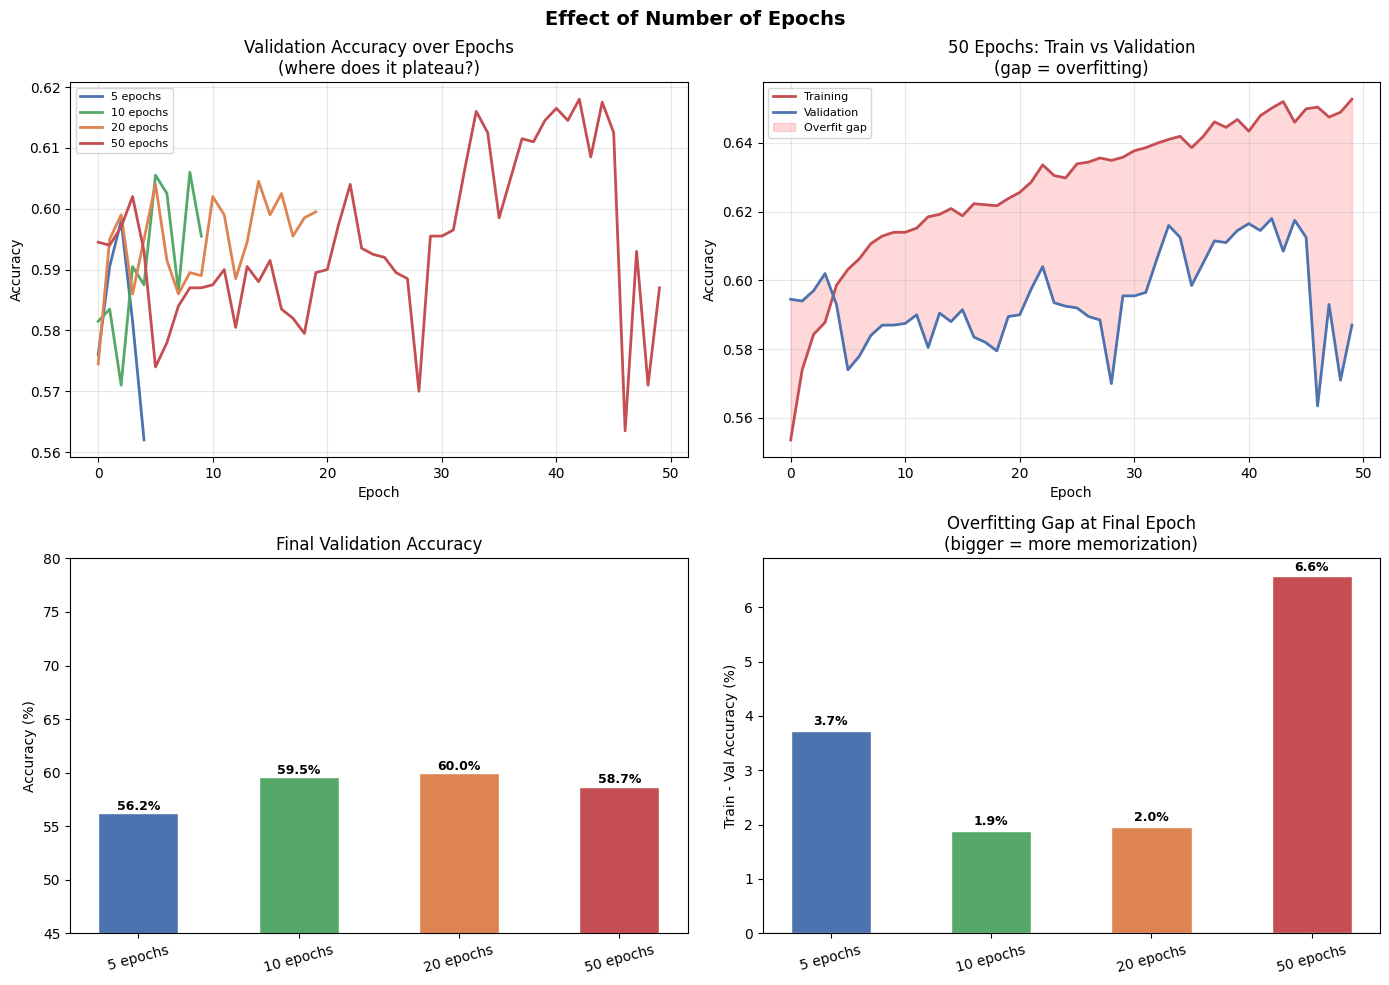

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Effect of Number of Epochs", fontsize=14, fontweight='bold')

colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

# Chart 1: Validation accuracy — all 4 on same plot
for (name, h), color in zip(histories_e.items(), colors):
    axes[0,0].plot(h.history['val_accuracy'], label=name, color=color, linewidth=2)
axes[0,0].set_title('Validation Accuracy over Epochs\n(where does it plateau?)')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(alpha=0.3)

# Chart 2: Train vs Val accuracy for 50 epochs only (overfitting most visible here)
h50 = histories_e["50 epochs"]
axes[0,1].plot(h50.history['accuracy'],     label='Training',   color='#C44E52', linewidth=2)
axes[0,1].plot(h50.history['val_accuracy'], label='Validation', color='#4C72B0', linewidth=2)
axes[0,1].fill_between(range(50),
                        h50.history['accuracy'],
                        h50.history['val_accuracy'],
                        alpha=0.15, color='red', label='Overfit gap')
axes[0,1].set_title('50 Epochs: Train vs Validation\n(gap = overfitting)')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(alpha=0.3)

# Chart 3: Final accuracy bar chart
names = list(accuracies_e.keys())
vals  = [v * 100 for v in accuracies_e.values()]
bars  = axes[1,0].bar(names, vals, color=colors, edgecolor='white', width=0.5)
axes[1,0].set_title('Final Validation Accuracy')
axes[1,0].set_ylabel('Accuracy (%)')
axes[1,0].set_ylim(45, 80)
axes[1,0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, vals):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Chart 4: Overfitting gap per config
gaps = [(histories_e[n].history['accuracy'][-1] - 
         histories_e[n].history['val_accuracy'][-1]) * 100 
        for n in names]
bars2 = axes[1,1].bar(names, gaps, color=colors, edgecolor='white', width=0.5)
axes[1,1].set_title('Overfitting Gap at Final Epoch\n(bigger = more memorization)')
axes[1,1].set_ylabel('Train - Val Accuracy (%)')
axes[1,1].tick_params(axis='x', rotation=15)
axes[1,1].axhline(0, color='black', linewidth=0.8)
for bar, gap in zip(bars2, gaps):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                   f'{gap:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('experiment_epochs.png', dpi=150, bbox_inches='tight')
plt.show()


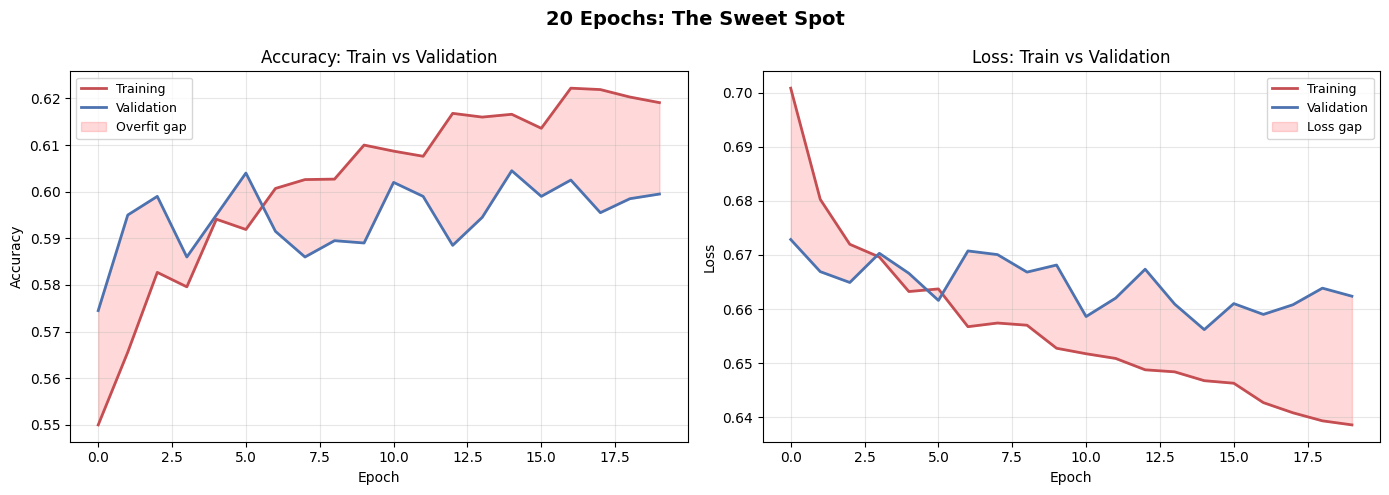

In [29]:
h20 = histories_e["20 epochs"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("20 Epochs: The Sweet Spot", fontsize=14, fontweight='bold')

# Chart 1: Accuracy
axes[0].plot(h20.history['accuracy'],     label='Training',   color='#C44E52', linewidth=2)
axes[0].plot(h20.history['val_accuracy'], label='Validation', color='#4C72B0', linewidth=2)
axes[0].fill_between(range(20),
                     h20.history['accuracy'],
                     h20.history['val_accuracy'],
                     alpha=0.15, color='red', label='Overfit gap')
axes[0].set_title('Accuracy: Train vs Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Chart 2: Loss
axes[1].plot(h20.history['loss'],     label='Training',   color='#C44E52', linewidth=2)
axes[1].plot(h20.history['val_loss'], label='Validation', color='#4C72B0', linewidth=2)
axes[1].fill_between(range(20),
                     h20.history['loss'],
                     h20.history['val_loss'],
                     alpha=0.15, color='red', label='Loss gap')
axes[1].set_title('Loss: Train vs Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('sweet_spot_20epochs.png', dpi=150, bbox_inches='tight')
plt.show()
